In [1]:
import pandas as pd
import numpy as np

# Conexión y consultas a base de datos Neo4j (grafo)
from neo4j import GraphDatabase

# Modelo de Machine Learning utilizado
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación de modelos
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score

# Visualización de resultados
import matplotlib.pyplot as plt

# Cálculo de curva ROC
from sklearn.metrics import roc_curve

# Herramientas para tuning de hiperparámetros
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

In [2]:
# Ruta base donde se encuentran los datasets
ruta_data =


In [3]:
# Conexión al servidor Neo4j 
driver = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "Tesis123"))

In [9]:
# Consulta Cypher para obtener relaciones de compra entre organismos e ítems
query = """
MATCH (o:Organismo)-[r:compra]->(a:Item)
RETURN o.nombre AS organismo, a.clase AS articulo
"""
# Ejecución de la consulta y transformación del resultado en un DataFrame de pandas
with driver.session() as session:
    result = session.run(query)
    df = pd.DataFrame([r.data() for r in result])

print(df.head())

                                           organismo           articulo
0  Secretaria General De La Presidencia De La Nación  PLANTA ORNAMENTAL
1  Secretaria General De La Presidencia De La Nación         HERBICIDAS
2  Secretaria General De La Presidencia De La Nación      CUERO VAQUETA
3  Secretaria General De La Presidencia De La Nación           SEMILLAS
4  Secretaria General De La Presidencia De La Nación  ARREGLOS FLORALES


In [10]:
# Inicialización de una nueva conexión al grafo 
graph = GraphDatabase.driver("bolt://localhost:7687", auth=("neo4j", "Tesis123"))

In [4]:
#leer el dataset
dataset=pd.read_csv(ruta_data+'dataset_link_prediction.csv', sep=',')

In [62]:
dataset

,organismo_codigo,item_clase,e.periodo,label,split,grado_organismo,grado_item,pref_attachment,co_compras,common_neighbors,total_neighbors,jaccard,adamic_adar,resource_allocation
0,301,CUERO VAQUETA,201807,1,train,948,4.0,3792.0,3.0,948.0,952.0,0.307992,426.299261,130.675597
1,301,HERBICIDAS,202204,1,train,948,6.0,5688.0,5.0,948.0,954.0,0.289643,426.299261,130.675597
2,301,ARREGLOS FLORALES,201805,1,train,948,2.0,1896.0,1.0,948.0,950.0,0.457308,426.299261,130.675597
3,301,FACTURAS,202209,1,test,948,3.0,2844.0,1.0,600.0,951.0,0.000000,223.349211,47.721315
4,301,SANDWICHES,201905,1,train,948,3.0,2844.0,2.0,948.0,951.0,0.418358,426.299261,130.675597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211972,173,VIDRIOS DE RELOJES,202208,0,train,2,6.0,12.0,1.0,2.0,8.0,0.000563,0.652737,0.098086
211973,173,ESPEJOS,202208,0,train,2,8.0,16.0,1.0,2.0,10.0,0.000631,0.652737,0.098086
211974,173,PALETAS DETECTORAS DE METALES,202208,0,train,2,2.0,4.0,1.0,1.0,4.0,0.001227,0.318929,0.045455
211975,173,PUERTAS ACCESO P/DISCAPACITADO,202212,0,test,2,1.0,2.0,1.0,1.0,3.0,0.000000,0.318929,0.045455


In [14]:
# Reemplazar NaN o valores faltantes por 0 en todas las columnas numéricas
dataset = dataset.fillna(0)

In [15]:
#Dividir el dataset en train y test

train = dataset[dataset["split"]=="train"]
test = dataset[dataset["split"]=="test"]


In [16]:
# Filtrar por train 
train_df = dataset[dataset['split'] == 'train']

# Separar positivos y negativos
positivos = train_df[train_df['label'] == 1]
negativos = train_df[train_df['label'] == 0]

# Igualar cantidad de negativos a positivos
negativos_balanceados = negativos.sample(n=len(positivos), random_state=42)

# Combinar ambos para el nuevo conjunto balanceado
train_balanceado = pd.concat([positivos, negativos_balanceados])

# Mezclar aleatoriamente
train= train_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)
train

,organismo_codigo,item_clase,e.periodo,label,split,grado_organismo,grado_item,pref_attachment,co_compras,common_neighbors,total_neighbors,jaccard,adamic_adar,resource_allocation
0,375,VIALES P/ LABORATORIO,202104,1,train,1139,9.0,10251.0,8.0,1139.0,1148.0,0.314467,563.650059,190.467633
1,329,BANDEJAS PORTAPAPELES,201612,1,train,113,31.0,3503.0,30.0,113.0,144.0,0.030214,38.670745,7.749222
2,367,GUANTES,201810,0,train,1,47.0,47.0,1.0,1.0,48.0,0.000288,0.286000,0.031250
3,106,REP. Y ACC. P/CONMUTADOR,202208,0,train,294,3.0,882.0,1.0,160.0,297.0,0.050778,67.025318,17.506358
4,804,RECEPTACULOS PLASTICOS,202208,0,train,132,5.0,660.0,1.0,111.0,137.0,0.031224,37.418305,6.999163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77601,112,CONECTORES,202112,1,train,331,27.0,8937.0,26.0,331.0,358.0,0.091336,133.106930,34.625889
77602,902,ESTILETES,202208,0,train,277,6.0,1662.0,1.0,229.0,283.0,0.069478,84.796259,18.418204
77603,338,INTERRUPTORES DIFERENCIALES,202208,0,train,150,14.0,2100.0,1.0,140.0,164.0,0.043573,42.669318,6.018003
77604,301,REP. Y ACC. P/HELICOPTERO,202012,1,train,948,5.0,4740.0,4.0,948.0,953.0,0.316951,426.299261,130.675597


In [17]:
# Filtrar por test
test_df = dataset[dataset['split'] == 'test']

# Separar positivos y negativos
positivos = test_df[test_df['label'] == 1]
negativos = test_df[test_df['label'] == 0]

# Igualar cantidad de negativos a positivos
negativos_balanceados = negativos.sample(n=len(positivos), random_state=42)

# Combinar ambos para el nuevo conjunto balanceado
test_balanceado = pd.concat([positivos, negativos_balanceados])

# Mezclar aleatoriamente
test= test_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)
test

,organismo_codigo,item_clase,e.periodo,label,split,grado_organismo,grado_item,pref_attachment,co_compras,common_neighbors,total_neighbors,jaccard,adamic_adar,resource_allocation
0,379,TOMACABLES P/JABALINA,202212,1,test,1595,6.0,9570.0,1.0,538.0,1601.0,0.0,244.448380,70.602300
1,106,REP. Y ACC. P/AUTOELEVADOR,202301,0,test,294,5.0,1470.0,1.0,230.0,299.0,0.0,96.971387,26.363107
2,173,RESALTADORES,202210,1,test,2,59.0,118.0,1.0,2.0,61.0,0.0,0.652737,0.098086
3,381,JERINGAS DESCARTABLES,202301,1,test,1407,23.0,32361.0,1.0,1137.0,1430.0,0.0,543.147091,168.059110
4,105,MARCADORES,202211,1,test,1303,59.0,76877.0,1.0,1016.0,1362.0,0.0,464.815642,138.606487
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30973,341,MAQUINA EMPAQUETADORA,202210,0,test,302,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.000000
30974,908,CHINCHES,202302,1,test,678,36.0,24408.0,1.0,613.0,714.0,0.0,249.851049,63.029217
30975,337,SEPARADORES,202209,1,test,780,20.0,15600.0,1.0,698.0,800.0,0.0,283.996416,71.019201
30976,250,MEDALLAS,202302,0,test,181,11.0,1991.0,1.0,160.0,192.0,0.0,50.592767,7.611968


In [18]:
# Definir el modelo base
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced_subsample')

# Definir el grid de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [100, 1000, 5000],
    'min_samples_leaf': [500, 1000,2000],
    'max_features': ['sqrt', 'log2']
}

# Usamos F1  como métrica principal
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=make_scorer(f1_score),
    cv=3,                 # validación cruzada 3-fold
    verbose=2,
    n_jobs=-1
)

X_train= train[columns]
y_train = train["label"]

# Entrenar el Grid Search
grid_search.fit(X_train, y_train)

# Mostrar los mejores parámetros encontrados
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

y_test = test["label"]

# Evaluar el modelo óptimo en el conjunto de test
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(test[columns])

from sklearn.metrics import classification_report
print("\n Evaluación en test:")
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 162 candidates, totalling 486 fits
✅ Mejores parámetros encontrados:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 500, 'min_samples_split': 100, 'n_estimators': 100}

📊 Evaluación en test:
              precision    recall  f1-score   support

           0       0.79      0.78      0.79     15489
           1       0.79      0.80      0.79     15489

    accuracy                           0.79     30978
   macro avg       0.79      0.79      0.79     30978
weighted avg       0.79      0.79      0.79     30978



In [20]:
#se va a usar como clasificador Random Forest
classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2000,
    min_samples_leaf=500,
    class_weight='balanced_subsample',  # recalcula pesos en cada árbol
    random_state=42,
    n_jobs=-1
)

#### Se corre el modelo con la variable Common_neighbors

In [21]:
columns = ["common_neighbors"]

X = train[columns]
y = train["label"]
classifier.fit(X, y)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=500,
                       min_samples_split=2000, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [22]:
def evaluate_model(predictions, actual):
    return pd.DataFrame({
        "Measure": ["Accuracy", "Precision", "Recall"],
        "Score": [accuracy_score(actual, predictions), 
                  precision_score(actual, predictions), 
                  recall_score(actual, predictions)]
    })

def feature_importance(columns, classifier):        
    display("Feature Importance")

    # Crear DataFrame con las importancias
    df = pd.DataFrame({
        "Feature": columns,
        "Importance": classifier.feature_importances_
    })

    # Calcular el porcentaje de importancia
    df["Importance (%)"] = 100 * df["Importance"] / df["Importance"].sum()

    # Ordenar de mayor a menor
    df = df.sort_values("Importance", ascending=False)

    # Gráfico de barras
    ax = df.plot(
        kind='bar',
        x='Feature',
        y='Importance (%)',
        legend=None,
        color="#4C72B0",
        figsize=(8, 5),
        title="Importancia relativa de las variables (%)"
    )

    # Etiquetas de los ejes
    ax.xaxis.set_label_text("")
    ax.yaxis.set_label_text("Importancia (%)")

     # Rotar etiquetas del eje X
    plt.xticks(rotation=40, ha='right')

    # Mostrar valores sobre cada barra
    for p in ax.patches:
        ax.text(
            p.get_x() + p.get_width() / 2,
            p.get_height() + 0.0,  # más espacio arriba de la barra
            f"{p.get_height():.1f}%",
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


,Measure,Score
0,Accuracy,0.790077
1,Precision,0.791186
2,Recall,0.788172


'Feature Importance'

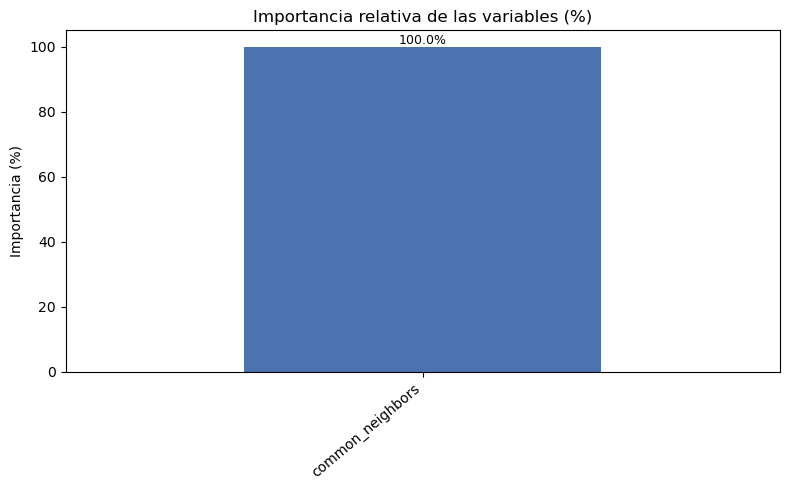

In [23]:
predictions = classifier.predict(test[columns])
y_test = test["label"]

display(evaluate_model(predictions, y_test))
feature_importance(columns, classifier)

#### Se corre el modelo con la variable total_neighbors

In [24]:
columns = ["total_neighbors"]

X = train[columns]
y = train["label"]
classifier.fit(X, y)

RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=500,
                       min_samples_split=2000, n_estimators=300, n_jobs=-1,
                       random_state=42)

,Measure,Score
0,Accuracy,0.762896
1,Precision,0.721449
2,Recall,0.856479


'Feature Importance'

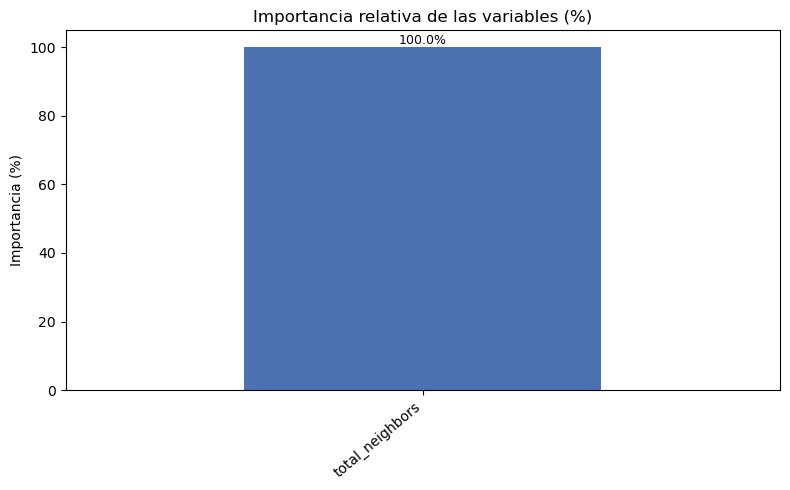

In [25]:
predictions = classifier.predict(test[columns])
y_test = test["label"]

display(evaluate_model(predictions, y_test))
feature_importance(columns, classifier)

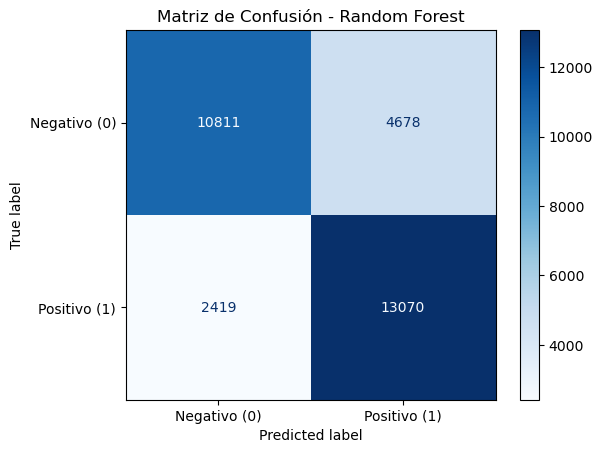

In [320]:
# Matriz de confusión
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo (0)", "Positivo (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

#### Se corre el modelo con la variable pref_attachment 

In [321]:
columns = ["pref_attachment"]

X = train[columns]
y = train["label"]
classifier.fit(X, y)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       max_features='log2', min_samples_leaf=500,
                       min_samples_split=100, n_jobs=-1, random_state=42)

,Measure,Score
0,Accuracy,0.846794
1,Precision,0.830330
2,Recall,0.871715


'Feature Importance'

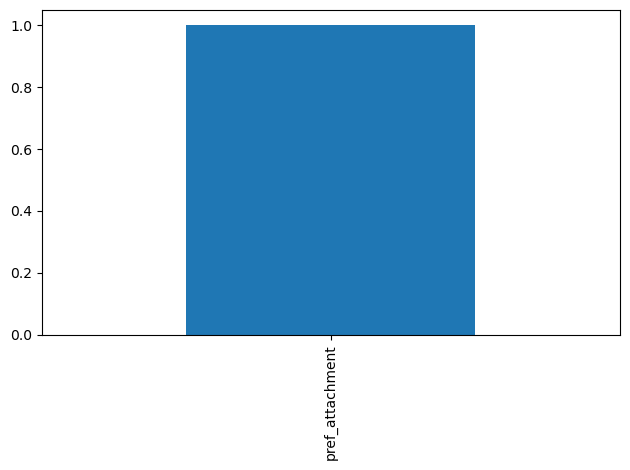

In [322]:
predictions = classifier.predict(test[columns])
y_test = test["label"]

display(evaluate_model(predictions, y_test))
feature_importance(columns, classifier)

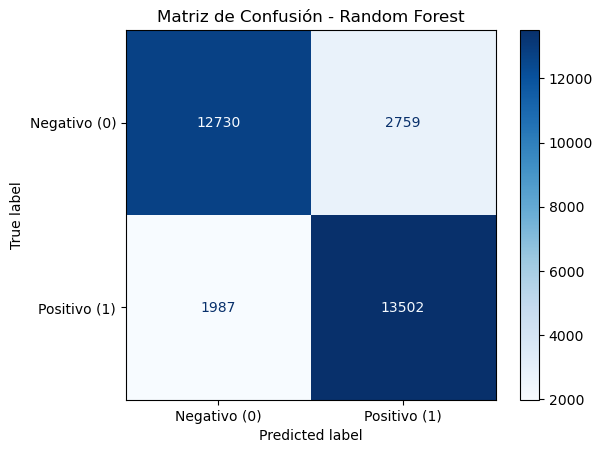

In [323]:
# Matriz de confusión
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo (0)", "Positivo (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

#### Se corre el modelo con las 3 variables common_neighbors, total_neighbors y pref_attachment

In [324]:
#probar con más variables
columns = ["common_neighbors","total_neighbors","pref_attachment"]

X = train[columns]
y = train["label"]
classifier.fit(X, y)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       max_features='log2', min_samples_leaf=500,
                       min_samples_split=100, n_jobs=-1, random_state=42)

,Measure,Score
0,Accuracy,0.832817
1,Precision,0.869216
2,Recall,0.783524


'Feature Importance'

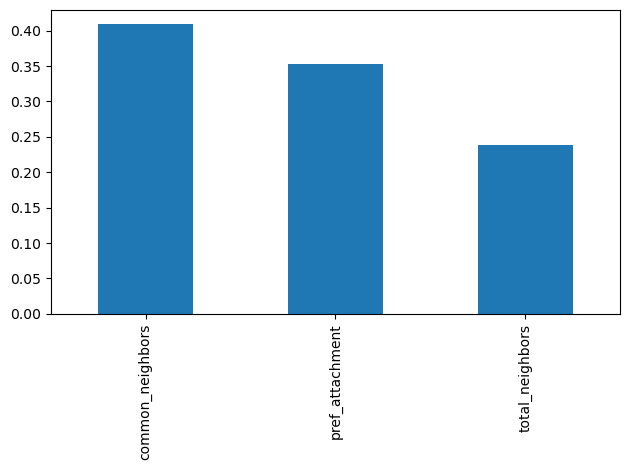

In [325]:
predictions = classifier.predict(test[columns])
y_test = test["label"]

display(evaluate_model(predictions, y_test))
feature_importance(columns, classifier)

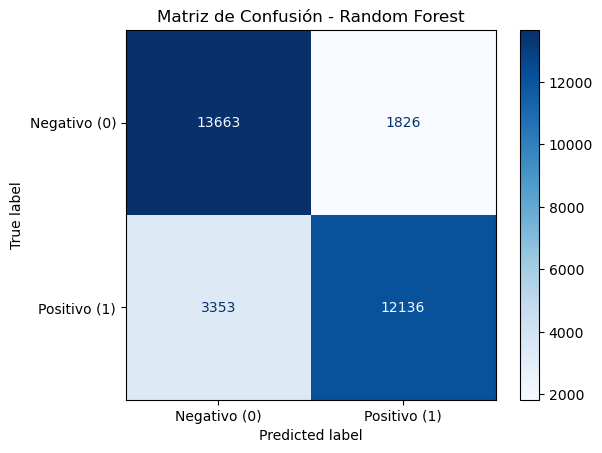

In [326]:
# Matriz de confusión
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo (0)", "Positivo (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

#### Se genera el modelo utilizando todas las variables del dataset

In [344]:
#probar con todas las variables
#probar con más variables
columns = ["grado_organismo","grado_item","pref_attachment","common_neighbors","total_neighbors","jaccard","adamic_adar","resource_allocation"]

X = train[columns]
y = train["label"]
classifier.fit(X, y)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       max_features='log2', min_samples_leaf=500,
                       min_samples_split=100, n_jobs=-1, random_state=42)

,Measure,Score
0,Accuracy,0.823068
1,Precision,0.905511
2,Recall,0.721415


'Feature Importance'

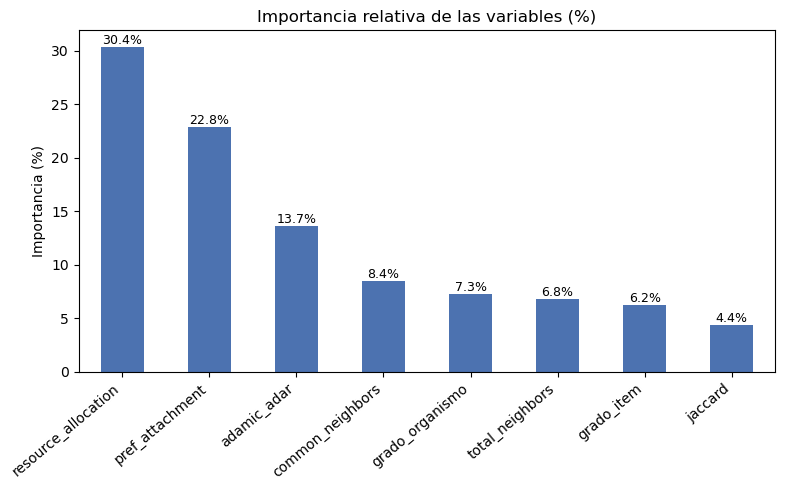

In [350]:
predictions = classifier.predict(test[columns])
y_test = test["label"]

# --- Probabilidades de clase positiva (para AUC) ---
y_pred_proba = classifier.predict_proba(test[columns])[:, 1]

display(evaluate_model(predictions, y_test))
feature_importance(columns, classifier)

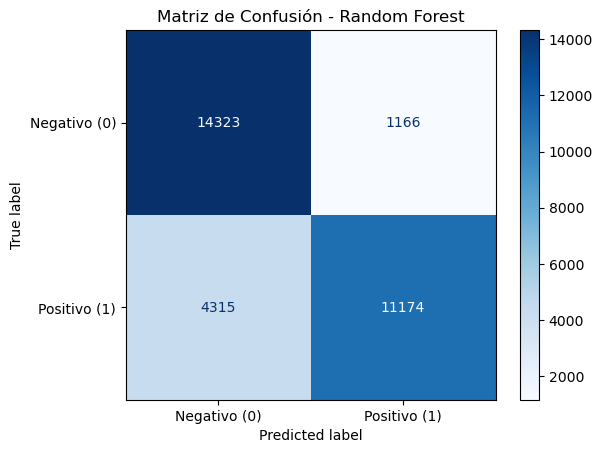

In [346]:
# Matriz de confusión
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo (0)", "Positivo (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

AUC: 0.9114942966257626


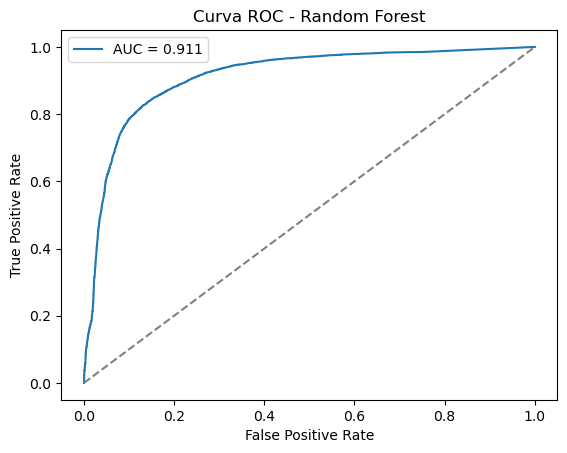

In [336]:

auc = roc_auc_score(y_test, y_pred_proba)
print("AUC:", auc)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('Curva ROC - Random Forest')
plt.show()